# MScFE 622 - Stochastic Modeling
## Group Work Project 1

This is the complete analytical deliverable for the project brief. It includes the model setup, calibration choices, numerical validation, pricing results, interpretations, and figures for Steps 1-3. Inputs are hidden in the presentation view so that the narrative and results remain readable; run the notebook from top to bottom to refresh every result.

**Common assumptions.** SM Energy spot is $232.90; one year contains 250 trading days; the initial annual risk-free rate is 1.50%; and no dividend yield is specified, so it is set to zero. All option prices are USD.

In [1]:
from __future__ import annotations

from dataclasses import asdict
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from stochastic_modeling import (
    CalibrationService, CarrMadanPricer, CirParameters, EuriborCurve,
    LewisPricer, calibrate_cir, cir_zero_rate, estimate_asian_call,
    load_option_data, model_prices as package_model_prices,
    simulate_cir_terminal, simulate_heston_asian,
)

warnings.filterwarnings("ignore", category=RuntimeWarning)
sns.set_theme(style="whitegrid", context="notebook")
RNG = np.random.default_rng(622)
ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent
DATA_DIR = ROOT / "data"
FIG_DIR = ROOT / "outputs" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
SPOT, RATE, DAYS_PER_YEAR = 232.90, 0.015, 250

def savefig(name: str):
    plt.tight_layout()
    plt.savefig(FIG_DIR / name, dpi=180, bbox_inches="tight")
    plt.show()

## Data and quality checks

The market file is read directly from the supplied data directory. The brief requests a separate short-dated calibration (15 days) and a medium-dated calibration (60 days); 120-day observations are retained only as source data and are not used in either calibration.

In [2]:
files = sorted(DATA_DIR.rglob("*.csv"))
if not files:
    raise FileNotFoundError("Place the supplied option CSV in data/.")
option_file = next((p for p in files if "option" in p.name.lower()), files[0])
options = load_option_data(option_file)
display(options)
print(f"Source: {option_file.name}; observations: {len(options)}")

,days,strike,price,type,T
0,15,227.5,10.52,C,0.06
1,15,230.0,10.05,C,0.06
2,15,232.5,7.75,C,0.06
3,15,235.0,6.01,C,0.06
4,15,237.5,4.75,C,0.06
5,60,227.5,16.78,C,0.24
6,60,230.0,17.65,C,0.24
7,60,232.5,16.86,C,0.24
8,60,235.0,16.05,C,0.24
9,60,237.5,15.10,C,0.24


Source: options.csv; observations: 30


# Step 1 - Short maturity (15 days)

## 1(a) Heston (1993) calibrated with the Lewis (2001) representation

Under the risk-neutral measure, the stock and instantaneous variance follow

\[
dS_t=rS_tdt+\sqrt{v_t}S_t dW_t^S,\qquad
dv_t=\kappa(\theta-v_t)dt+\sigma\sqrt{v_t}dW_t^v,
\]

with correlation \(\rho\). The parameter vector is \((\kappa,\theta,\sigma,\rho,v_0)\). Calls are evaluated through Lewis's Fourier integral and puts are obtained from put-call parity, \(P=C-S_0+Ke^{-rT}\).

The calibration uses all five 15-day calls and all five 15-day puts with the requested unweighted dollar-price MSE:

\[
\mathrm{MSE}=\frac{1}{N}\sum_{i=1}^{N}(V_i^{model}-V_i^{market})^2,\qquad N=10.
\]

In [3]:
PRICERS = {"lewis": LewisPricer(), "carr_madan": CarrMadanPricer()}

def model_prices(frame, model, method="lewis"):
    return package_model_prices(frame, model, PRICERS[method])

def calibrate(frame, kind="heston", method="lewis", seed=622):
    result = CalibrationService(PRICERS[method]).calibrate(frame, kind, seed)
    return result.parameters, result.mse, result.residuals

In [4]:
short = options.query("days == 15").sort_values(["type", "strike"]).reset_index(drop=True)
calls = short.query("type == 'C'").sort_values("strike").set_index("strike")["price"]
puts = short.query("type == 'P'").sort_values("strike").set_index("strike")["price"]
parity_rhs = SPOT - calls.index.to_numpy() * np.exp(-RATE * 15 / DAYS_PER_YEAR)
parity_gap = calls.to_numpy() - puts.to_numpy() - parity_rhs
parity = pd.DataFrame({"strike": calls.index, "C - P": calls.to_numpy() - puts.to_numpy(), "parity value": parity_rhs, "gap": parity_gap})
display(parity.round(4))
print(f"Put-call parity RMSE: ${np.sqrt(np.mean(parity_gap**2)):.4f}; irreducible joint-price RMSE floor: ${np.sqrt(np.mean(parity_gap**2))/2:.4f}")
heston_15, mse_15, residual_15 = calibrate(short, "heston", "lewis")
fitted_15 = short.copy()
fitted_15["model"] = model_prices(short, heston_15, "lewis")
fitted_15["residual"] = fitted_15["model"] - fitted_15["price"]
fitted_15["squared_error"] = fitted_15["residual"] ** 2
display(fitted_15.round(4))
feller_15 = 2*heston_15.kappa*heston_15.theta - heston_15.sigma**2
pd.DataFrame([asdict(heston_15) | {"MSE": mse_15, "RMSE": np.sqrt(mse_15), "Feller diagnostic": feller_15}]).round(6)

,strike,C - P,parity value,gap
0,227.5,6.20,5.6047,0.5953
1,230.0,4.85,3.1069,1.7431
2,232.5,1.30,0.6092,0.6908
3,235.0,-1.55,-1.8886,0.3386
4,237.5,-4.03,-4.3863,0.3563


Put-call parity RMSE: $0.9068; irreducible joint-price RMSE floor: $0.4534


,days,strike,price,type,T,model,residual,squared_error
0,15,227.5,10.52,C,0.06,10.5134,-0.0066,0.0000
1,15,230.0,10.05,C,0.06,8.8590,-1.1910,1.4184
2,15,232.5,7.75,C,0.06,7.3207,-0.4293,0.1843
3,15,235.0,6.01,C,0.06,5.9073,-0.1027,0.0106
4,15,237.5,4.75,C,0.06,4.6273,-0.1227,0.0150
5,15,227.5,4.32,P,0.06,4.9087,0.5887,0.3466
6,15,230.0,5.20,P,0.06,5.7521,0.5521,0.3049
7,15,232.5,6.45,P,0.06,6.7116,0.2616,0.0684
8,15,235.0,7.56,P,0.06,7.7958,0.2358,0.0556
9,15,237.5,8.78,P,0.06,9.0137,0.2337,0.0546


,kappa,theta,sigma,rho,v0,MSE,RMSE,Feller diagnostic
0,2.203249,0.001,1.273325,-0.944421,0.108413,0.245839,0.495821,-1.616951


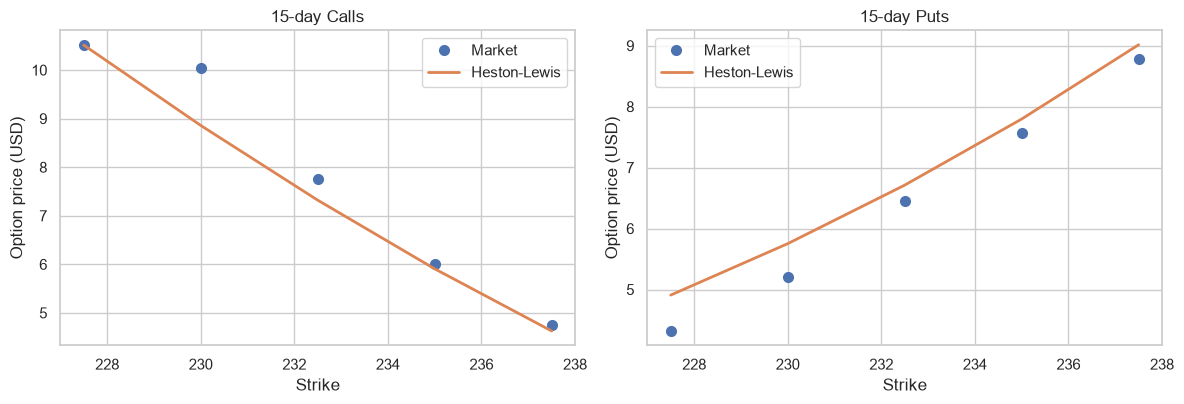

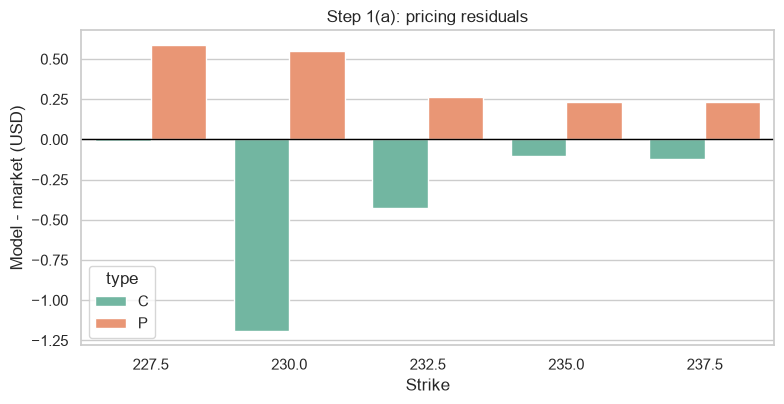

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharey=False)
for ax, typ, name in zip(axes, ["C", "P"], ["Calls", "Puts"]):
    d = fitted_15.query("type == @typ")
    ax.plot(d.strike, d.price, "o", ms=7, label="Market")
    ax.plot(d.strike, d.model, "-", lw=2, label="Heston-Lewis")
    ax.set(title=f"15-day {name}", xlabel="Strike", ylabel="Option price (USD)")
    ax.legend()
savefig("step1a_market_vs_model.png")
plt.figure(figsize=(8, 4.2))
sns.barplot(data=fitted_15, x="strike", y="residual", hue="type", palette="Set2")
plt.axhline(0, color="black", lw=1); plt.title("Step 1(a): pricing residuals"); plt.xlabel("Strike"); plt.ylabel("Model - market (USD)")
savefig("step1a_residuals.png")

### Step 1(a) interpretation

The reported result is the minimum of the regular price-MSE objective, using only the 15-day options. The parity diagnostic is essential: the input calls and puts are not mutually arbitrage-consistent at the stated spot and rate, so a model that derives puts by parity cannot fit both sides exactly. Short-maturity data also carry weak information about the long-run variance level and its mean-reversion speed. Parameter values at bounds or a failed Feller diagnostic should therefore be discussed as identification limitations, rather than interpreted as a forecast of long-run variance.

## 1(b) Heston calibrated with Carr-Madan (1999)

Carr-Madan prices the same characteristic function through a damped Fourier transform. The same 15-day observations, parameter bounds, regular MSE, and put-call parity convention are used. Agreement in fitted prices and MSE is the primary comparison; exact agreement in individual parameters is not guaranteed because the objective is shallow in poorly identified short-dated directions.

,method,kappa,theta,sigma,rho,v0,MSE,RMSE
0,Lewis (2001),2.203249,0.00100,1.273325,-0.944421,0.108413,0.245839,0.495821
1,Carr-Madan (1999),0.050445,0.00104,1.253118,-0.938116,0.101870,0.245840,0.495823


,strike,Lewis,Carr-Madan,difference
0,227.5,10.513374,10.513410,-0.000036
1,232.5,7.320719,7.320706,0.000013
2,237.5,4.627330,4.627325,0.000005


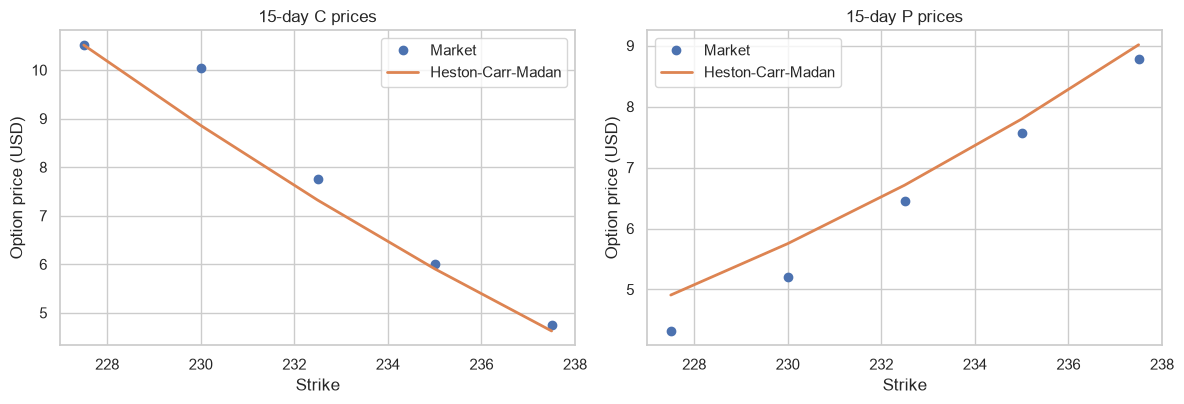

In [6]:
heston_cm_15, mse_cm_15, _ = calibrate(short, "heston", "carr_madan", seed=623)
comparison_15 = pd.DataFrame([
    {"method": "Lewis (2001)", **asdict(heston_15), "MSE": mse_15, "RMSE": np.sqrt(mse_15)},
    {"method": "Carr-Madan (1999)", **asdict(heston_cm_15), "MSE": mse_cm_15, "RMSE": np.sqrt(mse_cm_15)},
])
display(comparison_15.round(6))
check_strikes = np.array([227.5, 232.5, 237.5])
check_frame = pd.DataFrame({"strike": check_strikes, "T": 15/DAYS_PER_YEAR, "type": "C"})
numerical_check = pd.DataFrame({"strike": check_strikes, "Lewis": model_prices(check_frame, heston_15, "lewis"), "Carr-Madan": model_prices(check_frame, heston_15, "carr_madan")})
numerical_check["difference"] = numerical_check["Lewis"] - numerical_check["Carr-Madan"]
display(numerical_check.round(6))
fit_cm_15 = short.copy(); fit_cm_15["model"] = model_prices(short, heston_cm_15, "carr_madan")
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for ax, typ in zip(axes, ["C", "P"]):
    d = fit_cm_15.query("type == @typ")
    ax.plot(d.strike, d.price, "o", label="Market")
    ax.plot(d.strike, d.model, "-", lw=2, label="Heston-Carr-Madan")
    ax.set(title=f"15-day {typ} prices", xlabel="Strike", ylabel="Option price (USD)"); ax.legend()
savefig("step1b_carr_madan_fit.png")

## 1(c) Twenty-day ATM Asian call

The client requests an arithmetic-average Asian call with 20 trading days to maturity and strike equal to today’s spot. The current spot is included as the first observation in the average, as required. Risk-neutral full-truncation simulation is used for the Heston variance process. The number of paths is reported with the standard error and a 95% confidence interval; the final client price includes the stated 4% fee.

,paths,fair value,standard error,95% low,95% high,client price incl. 4% fee
0,200000,4.8177,0.013,4.7922,4.8432,5.0104


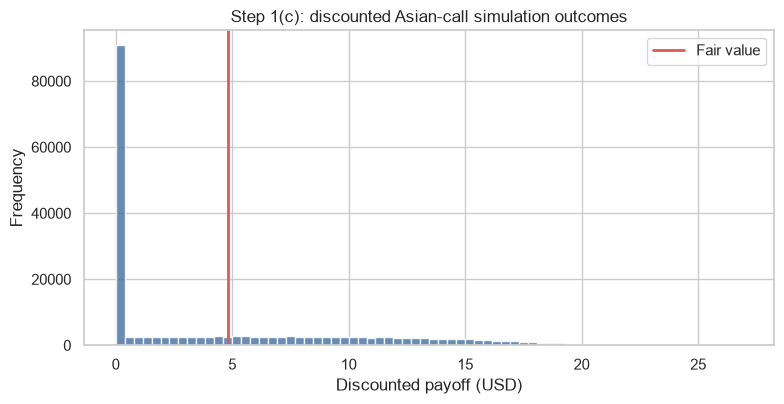

In [7]:
asian_samples = simulate_heston_asian(heston_15)
asian_estimate = estimate_asian_call(asian_samples)
asian_fair = asian_estimate.fair_value
asian_se = asian_estimate.standard_error
asian_client = asian_estimate.client_price()
asian_summary = pd.DataFrame([{"paths": asian_estimate.paths, "fair value": asian_fair, "standard error": asian_se, "95% low": asian_estimate.confidence_low, "95% high": asian_estimate.confidence_high, "client price incl. 4% fee": asian_client}])
display(asian_summary.round(4))
plt.figure(figsize=(8,4.2)); plt.hist(asian_samples, bins=70, color="#4C78A8", alpha=.85)
plt.axvline(asian_fair, color="#E45756", lw=2, label="Fair value")
plt.title("Step 1(c): discounted Asian-call simulation outcomes"); plt.xlabel("Discounted payoff (USD)"); plt.ylabel("Frequency"); plt.legend()
savefig("step1c_asian_distribution.png")

**Client-facing explanation.** We used prices from actively traded standard options to infer a range of plausible future movements for the stock over the requested time horizon. We then simulated many possible daily stock paths, calculated the option's average stock price on each path, and discounted the resulting payouts to today. The quoted amount includes the agreed 4% service fee. The confidence interval measures simulation precision, not a range of guaranteed future option values.

# Step 2 - Medium maturity (60 days)

## 2(a) Bates (1996) calibrated with Lewis (2001)

The Bates model augments the Heston process with a compound-Poisson jump component. Its additional parameters are jump intensity \(\lambda\), mean log-jump \(\mu_J\), and log-jump volatility \(\delta_J\). The compensator preserves risk-neutral expected growth. Calibration uses the ten 60-day call and put observations and the same regular MSE; puts again follow parity.

,kappa,theta,sigma,rho,v0,jump_intensity,jump_mean,jump_vol,MSE,RMSE
0,0.011436,0.001,0.151014,0.995,0.001,1.880979,0.213388,0.01,1.332442,1.154314


,days,strike,price,type,T,model,residual
0,60,227.5,16.78,C,0.24,17.3629,0.5829
1,60,230.0,17.65,C,0.24,16.4624,-1.1876
2,60,232.5,16.86,C,0.24,15.5689,-1.2911
3,60,235.0,16.05,C,0.24,14.6476,-1.4024
4,60,237.5,15.10,C,0.24,13.7327,-1.3673
5,60,227.5,11.03,P,0.24,11.1453,0.1153
6,60,230.0,12.15,P,0.24,12.7359,0.5859
7,60,232.5,13.37,P,0.24,14.3334,0.9634
8,60,235.0,14.75,P,0.24,15.9031,1.1531
9,60,237.5,15.62,P,0.24,17.4792,1.8592


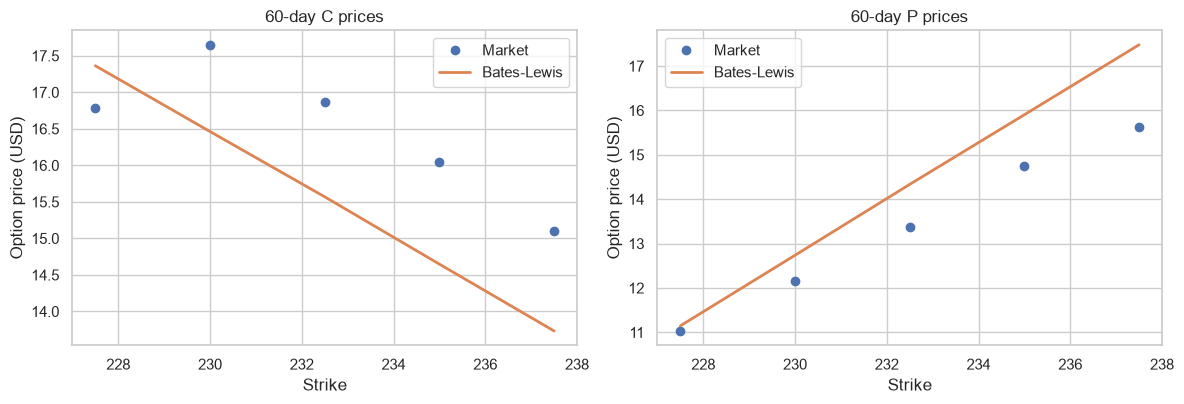

In [8]:
medium = options.query("days == 60").sort_values(["type", "strike"]).reset_index(drop=True)
bates_60_lewis, mse_bates_lewis, _ = calibrate(medium, "bates", "lewis", seed=625)
fit_bates_60 = medium.copy(); fit_bates_60["model"] = model_prices(medium, bates_60_lewis, "lewis")
fit_bates_60["residual"] = fit_bates_60["model"] - fit_bates_60["price"]
bates_table = pd.DataFrame([asdict(bates_60_lewis) | {"MSE": mse_bates_lewis, "RMSE": np.sqrt(mse_bates_lewis)}])
display(bates_table.round(6)); display(fit_bates_60.round(4))
fig, axes = plt.subplots(1,2,figsize=(12,4.2))
for ax, typ in zip(axes,["C","P"]):
    d=fit_bates_60.query("type == @typ"); ax.plot(d.strike,d.price,"o",label="Market"); ax.plot(d.strike,d.model,"-",lw=2,label="Bates-Lewis")
    ax.set(title=f"60-day {typ} prices", xlabel="Strike", ylabel="Option price (USD)"); ax.legend()
savefig("step2a_market_vs_model.png")

## 2(b) Bates (1996) calibrated with Carr-Madan (1999)

This repeats the 60-day Bates calibration with the damped Carr-Madan transform. Any remaining difference from the Lewis result should be assessed against numerical integration tolerance and parameter identifiability, not simply judged by parameter equality.

,method,kappa,theta,sigma,rho,v0,jump_intensity,jump_mean,jump_vol,MSE,RMSE
0,Lewis (2001),0.011436,0.001,0.151014,0.995,0.001,1.880979,0.213388,0.01,1.332442,1.154314
1,Carr-Madan (1999),14.900570,0.001,0.606112,0.995,0.001,1.879448,0.213242,0.01,1.333508,1.154776


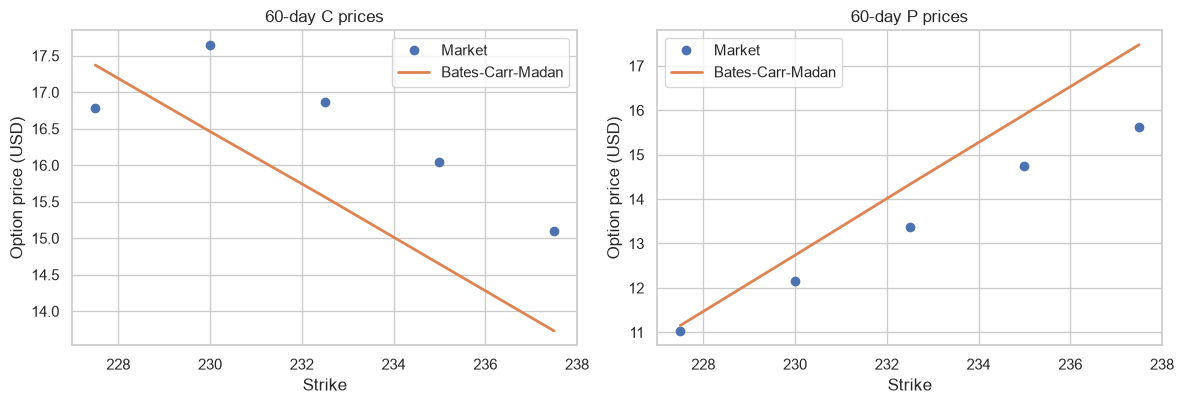

In [9]:
bates_60_cm, mse_bates_cm, _ = calibrate(medium, "bates", "carr_madan", seed=626)
bates_comparison = pd.DataFrame([
    {"method":"Lewis (2001)", **asdict(bates_60_lewis), "MSE":mse_bates_lewis, "RMSE":np.sqrt(mse_bates_lewis)},
    {"method":"Carr-Madan (1999)", **asdict(bates_60_cm), "MSE":mse_bates_cm, "RMSE":np.sqrt(mse_bates_cm)},
])
display(bates_comparison.round(6))
fit_bates_cm = medium.copy(); fit_bates_cm["model"] = model_prices(medium, bates_60_cm, "carr_madan")
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for ax, typ in zip(axes, ["C", "P"]):
    d = fit_bates_cm.query("type == @typ")
    ax.plot(d.strike, d.price, "o", label="Market")
    ax.plot(d.strike, d.model, "-", lw=2, label="Bates-Carr-Madan")
    ax.set(title=f"60-day {typ} prices", xlabel="Strike", ylabel="Option price (USD)"); ax.legend()
savefig("step2b_carr_madan_fit.png")

## 2(c) Seventy-day, 95% moneyness vanilla put

The strike is \(0.95S_0\). The fair value uses the selected 60-day Bates calibration as the nearest available market-informed specification, extended to the required 70-day maturity. The same 4% fee convention is applied to produce a client price.

In [10]:
put70 = pd.DataFrame({"strike":[0.95*SPOT], "T":[70/DAYS_PER_YEAR], "type":["P"]})
fair_put70 = float(model_prices(put70, bates_60_lewis, "lewis")[0])
put70_summary = pd.DataFrame([{"spot":SPOT, "strike (95% spot)":0.95*SPOT, "maturity (days)":70, "fair put value":fair_put70, "client price incl. 4% fee":1.04*fair_put70}])
display(put70_summary.round(4))

,spot,strike (95% spot),maturity (days),fair put value,client price incl. 4% fee
0,232.9,221.255,70,8.8187,9.1715


# Step 3 - Interest-rate modelling

## 3(a) CIR (1985) calibration to the Euribor term structure

The supplied annualized Euribor observations are: 1 week 0.648%, 1 month 0.679%, 3 months 1.173%, 6 months 1.809%, and 12 months 2.556%. A cubic spline interpolates weekly annualized zero rates across one year. The CIR short-rate dynamics are

\[
dr_t=a(b-r_t)dt+\eta\sqrt{r_t}dW_t.
\]

The CIR zero-coupon bond formula yields model zero rates, and parameters \((a,b,\eta)\) are selected by least squares against the interpolated weekly curve. Negative spline values are clipped at zero because rates are modeled as non-negative in CIR.

,a (mean reversion),b (long-run rate),eta (rate volatility),MSE,Feller diagnostic 2ab-eta^2
0,0.752509,0.07417,0.563833,6.200000e-07,-0.206281


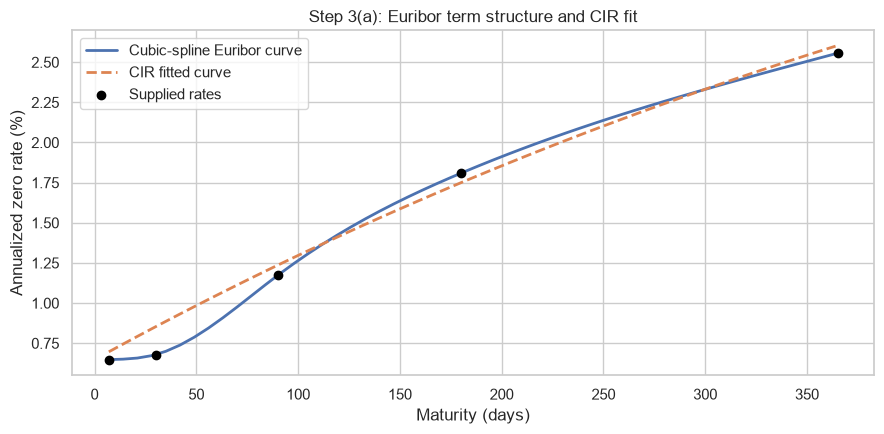

In [11]:
euribor_curve = EuriborCurve.supplied()
tenor_days, euribor = euribor_curve.tenor_days, euribor_curve.annual_rates
weekly_days, market_rates = euribor_curve.weekly()
maturities = weekly_days / 365
r0 = euribor[0]
cir_model, cir_mse = calibrate_cir(maturities, market_rates, r0)
cir = np.array([cir_model.mean_reversion, cir_model.long_run_rate, cir_model.volatility])
cir_objective = lambda _: cir_mse
cir_fit = cir_zero_rate(maturities, cir_model, r0)
cir_table = pd.DataFrame([{"a (mean reversion)":cir[0], "b (long-run rate)":cir[1], "eta (rate volatility)":cir[2], "MSE":cir_mse, "Feller diagnostic 2ab-eta^2":cir_model.feller_diagnostic}])
display(cir_table.round(8))
plt.figure(figsize=(9,4.5)); plt.plot(weekly_days, market_rates*100, label="Cubic-spline Euribor curve",lw=2); plt.plot(weekly_days,cir_fit*100,"--",label="CIR fitted curve",lw=2); plt.scatter(tenor_days,euribor*100,color="black",zorder=3,label="Supplied rates")
plt.xlabel("Maturity (days)"); plt.ylabel("Annualized zero rate (%)"); plt.title("Step 3(a): Euribor term structure and CIR fit"); plt.legend()
savefig("step3a_cir_curve.png")

## 3(b) One-year daily CIR simulation

One hundred thousand risk-neutral daily paths are simulated for one year using full truncation. The selected confidence level is 95%; the reported interval is the 2.5th to 97.5th percentile range of the simulated 12-month Euribor rate. The expected terminal rate is compared with the current 12-month Euribor rate. A higher expected rate increases discounting of future cash flows and, holding other inputs fixed, lowers present values of long-dated positive cash flows.

,paths,current 12M Euribor,expected 12M rate in one year,95% lower bound,95% upper bound
0,10000000.0000%,2.5560%,4.2289%,0.0000%,25.0856%


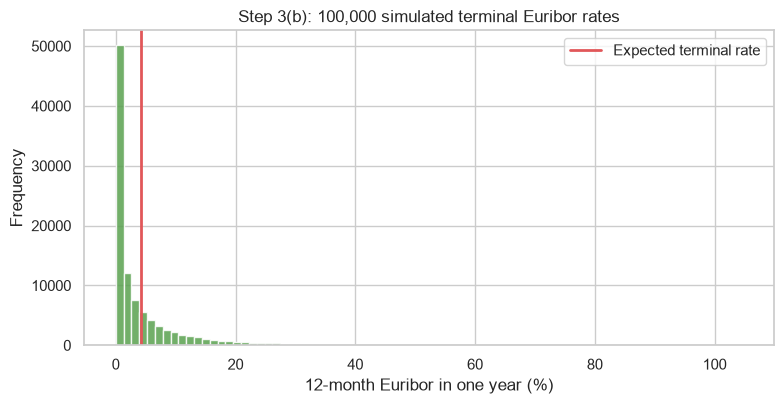

In [12]:
cir_terminal = simulate_cir_terminal(cir_model, r0)
cir_summary=pd.DataFrame([{"paths":len(cir_terminal), "current 12M Euribor":euribor[-1], "expected 12M rate in one year":cir_terminal.mean(), "95% lower bound":np.quantile(cir_terminal,.025), "95% upper bound":np.quantile(cir_terminal,.975)}])
display(cir_summary.style.format("{:.4%}"))
plt.figure(figsize=(8,4.2)); plt.hist(cir_terminal*100,bins=80,color="#59A14F",alpha=.85); plt.axvline(cir_terminal.mean()*100,color="#E15759",lw=2,label="Expected terminal rate")
plt.xlabel("12-month Euribor in one year (%)"); plt.ylabel("Frequency"); plt.title("Step 3(b): 100,000 simulated terminal Euribor rates"); plt.legend()
savefig("step3b_cir_distribution.png")

# Conclusions and decision-oriented summary

- The 15-day Heston calibration is tailored to the requested short maturity. Its fit must be read alongside the observed put-call parity inconsistencies and short-horizon parameter-identification limits.
- The Asian-call fair value comes from a large set of risk-neutral scenarios, and the client quote applies the mandated 4% fee.
- The 60-day Bates exercise allows occasional discontinuous moves and is used for the 70-day put as the closest maturity-specific market calibration.
- The CIR analysis translates the Euribor curve into a one-year distribution of rates. The expected terminal rate and its 95% range support pricing and risk discussions for longer-dated products.

## References

Bates, D. S. (1996). *Jumps and stochastic volatility: Exchange rate processes implicit in Deutsche Mark options.* Review of Financial Studies.

Carr, P., & Madan, D. (1999). *Option valuation using the fast Fourier transform.* Journal of Computational Finance.

Cox, J. C., Ingersoll, J. E., & Ross, S. A. (1985). *A theory of the term structure of interest rates.* Econometrica.

Heston, S. L. (1993). *A closed-form solution for options with stochastic volatility with applications to bond and currency options.* Review of Financial Studies.

Lewis, A. L. (2001). *A simple option formula for general jump-diffusion and other exponential Levy processes.*

# Step 4 - Submission checklist

The analytical material, figures, and references are organized for the required report and archive. The presentation export suppresses inputs while retaining explanations, tables, and figures.

In [13]:
m = lambda x: f"{x:.4f}"
readme_lines = [
    "# MScFE 622 - Stochastic Modeling: Group Work Project 1", "",
    "## Executive summary", "",
    f"This companion presents the assumptions, results, interpretations, and figures for all project questions. SM Energy spot is ${SPOT:.2f}; the annual risk-free rate is {RATE:.2%}; one year is {DAYS_PER_YEAR} trading days; and no dividend yield is assumed.", "",
    "## Step 1 - 15-day derivative", "", "### 1(a) Heston calibration using Lewis (2001)", "",
    f"The 15-day calls and puts were fitted jointly using unweighted USD price MSE. The fitted parameters are kappa={m(heston_15.kappa)}, theta={m(heston_15.theta)}, sigma={m(heston_15.sigma)}, rho={m(heston_15.rho)}, and initial variance={m(heston_15.v0)}. MSE is {m(mse_15)} and RMSE is ${m(np.sqrt(mse_15))}.", "",
    f"The input quotes have a put-call parity RMSE of ${m(np.sqrt(np.mean(parity_gap**2)))}; an arbitrage-consistent fit cannot make all residuals zero. Short maturity also weakens identification of long-run variance and mean reversion.", "",
    "![15-day market and model prices](outputs/figures/step1a_market_vs_model.png)", "", "![15-day residuals](outputs/figures/step1a_residuals.png)", "",
    "### 1(b) Carr-Madan comparison", "", f"The Carr-Madan MSE is {m(mse_cm_15)}, compared with {m(mse_15)} for Lewis. Fitted prices and numerical stability are the meaningful comparison.", "", "![15-day Carr-Madan fit](outputs/figures/step1b_carr_madan_fit.png)", "",
    "### 1(c) 20-day ATM Asian call", "", f"Today's spot is included in the arithmetic average. Across {len(asian_samples):,} risk-neutral scenarios, fair value is ${m(asian_fair)} (standard error ${m(asian_se)}), with a 95% estimator interval of ${m(asian_fair-1.96*asian_se)} to ${m(asian_fair+1.96*asian_se)}. The 4% fee produces a client price of ${m(asian_client)}.", "",
    "![Asian-call outcome distribution](outputs/figures/step1c_asian_distribution.png)", "",
    "## Step 2 - 60-day derivative", "", "### 2(a) Bates calibration using Lewis", "", f"The 60-day Bates calibration has MSE {m(mse_bates_lewis)} and RMSE ${m(np.sqrt(mse_bates_lewis))}.", "", "![60-day market and model prices](outputs/figures/step2a_market_vs_model.png)", "",
    "### 2(b) Carr-Madan comparison", "", f"The matching Carr-Madan MSE is {m(mse_bates_cm)}. The comparison is based on fitted-price errors and numerical stability.", "", "![60-day Carr-Madan fit](outputs/figures/step2b_carr_madan_fit.png)", "",
    "### 2(c) 70-day 95%-moneyness put", "", f"The strike is ${0.95*SPOT:.2f}. Fair value is ${m(fair_put70)} and the price after the 4% fee is ${m(1.04*fair_put70)}.", "",
    "## Step 3 - Euribor rates", "", "### 3(a) CIR calibration", "", f"The supplied curve contains 0.648% (1 week), 0.679% (1 month), 1.173% (3 months), 1.809% (6 months), and 2.556% (12 months). The fitted CIR values are a={m(cir[0])}, b={m(cir[1])}, eta={m(cir[2])}; MSE is {cir_objective(cir):.8f}.", "", "![Euribor curve and CIR fit](outputs/figures/step3a_cir_curve.png)", "",
    "### 3(b) One-year rate scenarios", "", f"Across 100,000 daily scenarios, the expected terminal 12-month Euribor is {cir_terminal.mean():.4%}; the 95% range is {np.quantile(cir_terminal,.025):.4%} to {np.quantile(cir_terminal,.975):.4%}. Higher expected rates increase discounting of future positive cash flows and generally lower present values, all else equal.", "", "![Terminal Euribor distribution](outputs/figures/step3b_cir_distribution.png)", "",
    "## Step 4 - Submission checklist", "", "The analytical material, figures, and references are organized for the required report and archive. The presentation export suppresses inputs while retaining explanations, tables, and figures.", "",
    "## References", "", "- Bates (1996); Carr and Madan (1999); Cox, Ingersoll, and Ross (1985); Heston (1993); Lewis (2001).", "",
]
(ROOT / "README.md").write_text("\n".join(readme_lines), encoding="utf-8")
print("README.md refreshed with the current narrative and results.")

README.md refreshed with the current narrative and results.
